In [1]:
!pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
    --------------------------------------- 1.0/44.0 MB 5.6 MB/s eta 0:00:08
   --- ------------------------------------ 3.9/44.0 MB 8.8 MB/s eta 0:00:05
   ----- ---------------------------------- 6.0/44.0 MB 9.0 MB/s eta 0:00:05
   ------- -------------------------------- 7.9/44.0 MB 9.0 MB/s eta 0:00:05
   --------- ------------------------------ 10.0/44.0 MB 9.1 MB/s eta 0:00:04
   ---------- ----------------------------- 11.8/44.0 MB 9.1 MB/s eta 0:00:04
   ------------ --------------------------- 13.6/44.0 MB 9.1 MB/s eta 0:00:04
   -------------- ------------------------- 15.7/44.0 MB 9.2 MB/s eta 0:00:04
   --------------- ------------------------ 17.6/44.0 MB 9.2 MB/s eta 0:00:03
   ----------------- ---------------------- 19.7/44.0 MB 9.3 MB/s eta 0:00:03
   ------------------- -------------------- 21.8/44.0 MB 9.3 MB/s eta 0:00:03
   ---

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

### Загрузка исходного изображения
Считываем изображение с помощью OpenCV. Так как OpenCV хранит цветные изображения в формате BGR, перед выводом через `matplotlib` переводим его в RGB.


<function matplotlib.pyplot.show(close=None, block=None)>

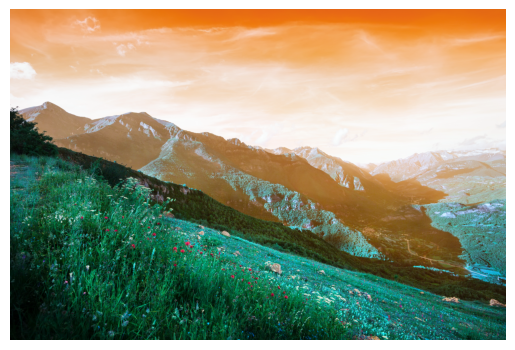

In [20]:
img_exm = cv2.imread("image_example.jpg")
#img_rgb = cv2.cvtColor(img_exm,cv2.COLOR_BGR2RGB)

plt.imshow(img_exm)
plt.axis("off")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

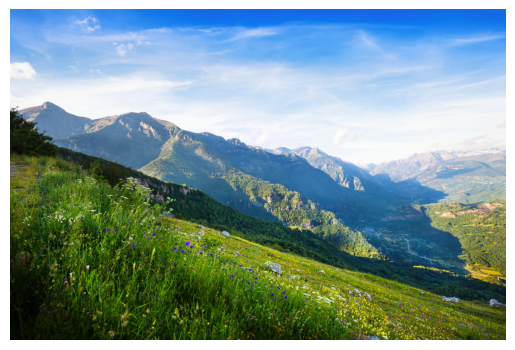

In [4]:
img_rgb = cv2.cvtColor(img_exm,cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.show

## Задание 1. Цвет пикселя в левом верхнем углу
У изображения левый верхний пиксель имеет координаты `[0, 0]`. Получаем его значение и выводим компоненты цвета отдельно. В OpenCV порядок каналов - BGR, поэтому сначала идёт синий, затем зелёный и красный.

In [5]:
b , g , r = img_exm[0,0]
print("Синий", b)
print("Зеленый", g)
print("Красный", r)

Синий 227
Зеленый 133
Красный 57


## Задание 2. Поиск пикселя с максимальной насыщенностью
Переводим изображение из BGR в HSV. В этой модели канал `S` отвечает за насыщенность цвета. Находим максимальное значение насыщенности и определяем координаты соответствующего пикселя.

Самый насыщенный [ 40 1034 ]


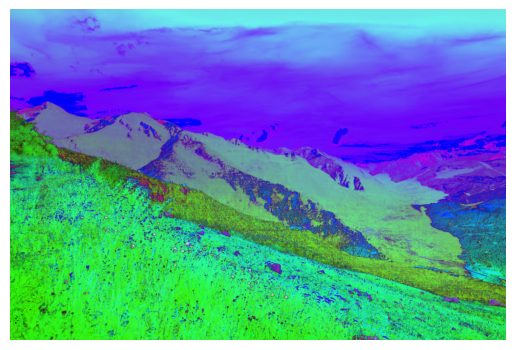

In [6]:
img_hsv = cv2.cvtColor(img_exm,cv2.COLOR_BGR2HSV)

plt.imshow(img_hsv)
plt.axis("off")
plt.show

saturation = img_hsv[:, :, 1]
y, x = np.unravel_index(np.argmax(saturation),saturation.shape)
print("Самый насыщенный [", x, y,"]")

## Задание 3. Разделение изображения на цветовые каналы
Разделяем исходное изображение на синий, зелёный и красный каналы. Каждый канал представляет собой одноканальное изображение, где яркость пикселя показывает интенсивность соответствующего цвета. Все три канала сохраняем в отдельные файлы.

Text(0.5, 1.0, 'красный канал')

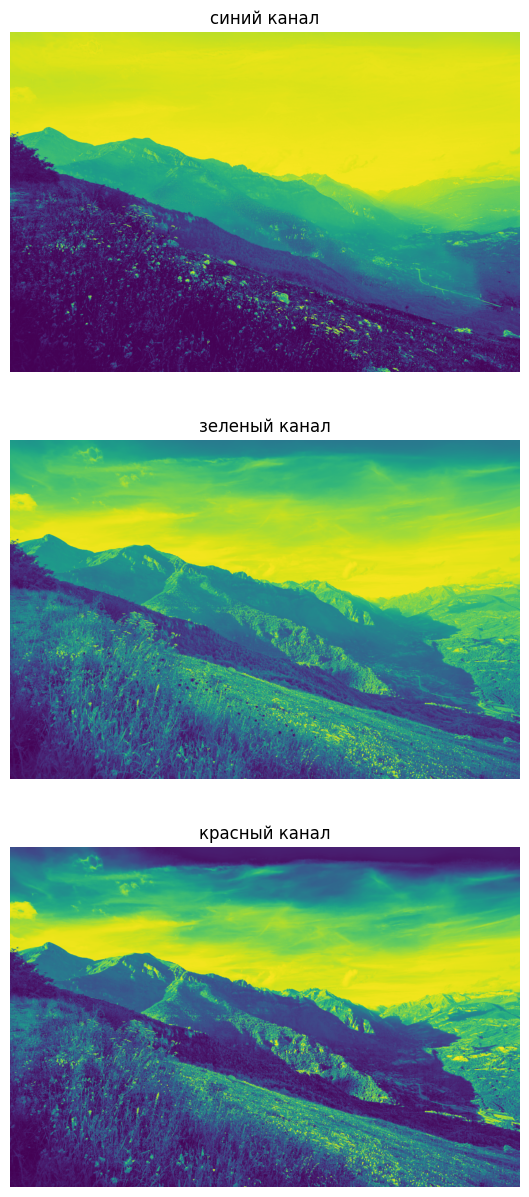

In [9]:
b_ch, g_ch, r_ch = cv2.split(img_exm)
plt.figure(figsize = (30,15))

cv2.imwrite("blue_channel.jpg", b_ch)
cv2.imwrite("green_channel.jpg", g_ch)
cv2.imwrite("red_channel.jpg", r_ch)

plt.subplot(3,1,1)
plt.imshow(b_ch)
plt.axis("off")
plt.title("синий канал")

plt.subplot(3,1,2)
plt.imshow(g_ch)
plt.axis("off")
plt.title("зеленый канал")

plt.subplot(3,1,3)
plt.imshow(r_ch)
plt.axis("off")
plt.title("красный канал")

## Задание 4. Изменение цвета нижней полосы
Создаём копию изображения, чтобы исходная картинка осталась без изменений. У копии выбираем последние 500 строк и задаём им зелёный цвет. В формате BGR зелёный задаётся значением `[0, 255, 0]`.

(np.float64(-0.5), np.float64(4499.5), np.float64(2999.5), np.float64(-0.5))

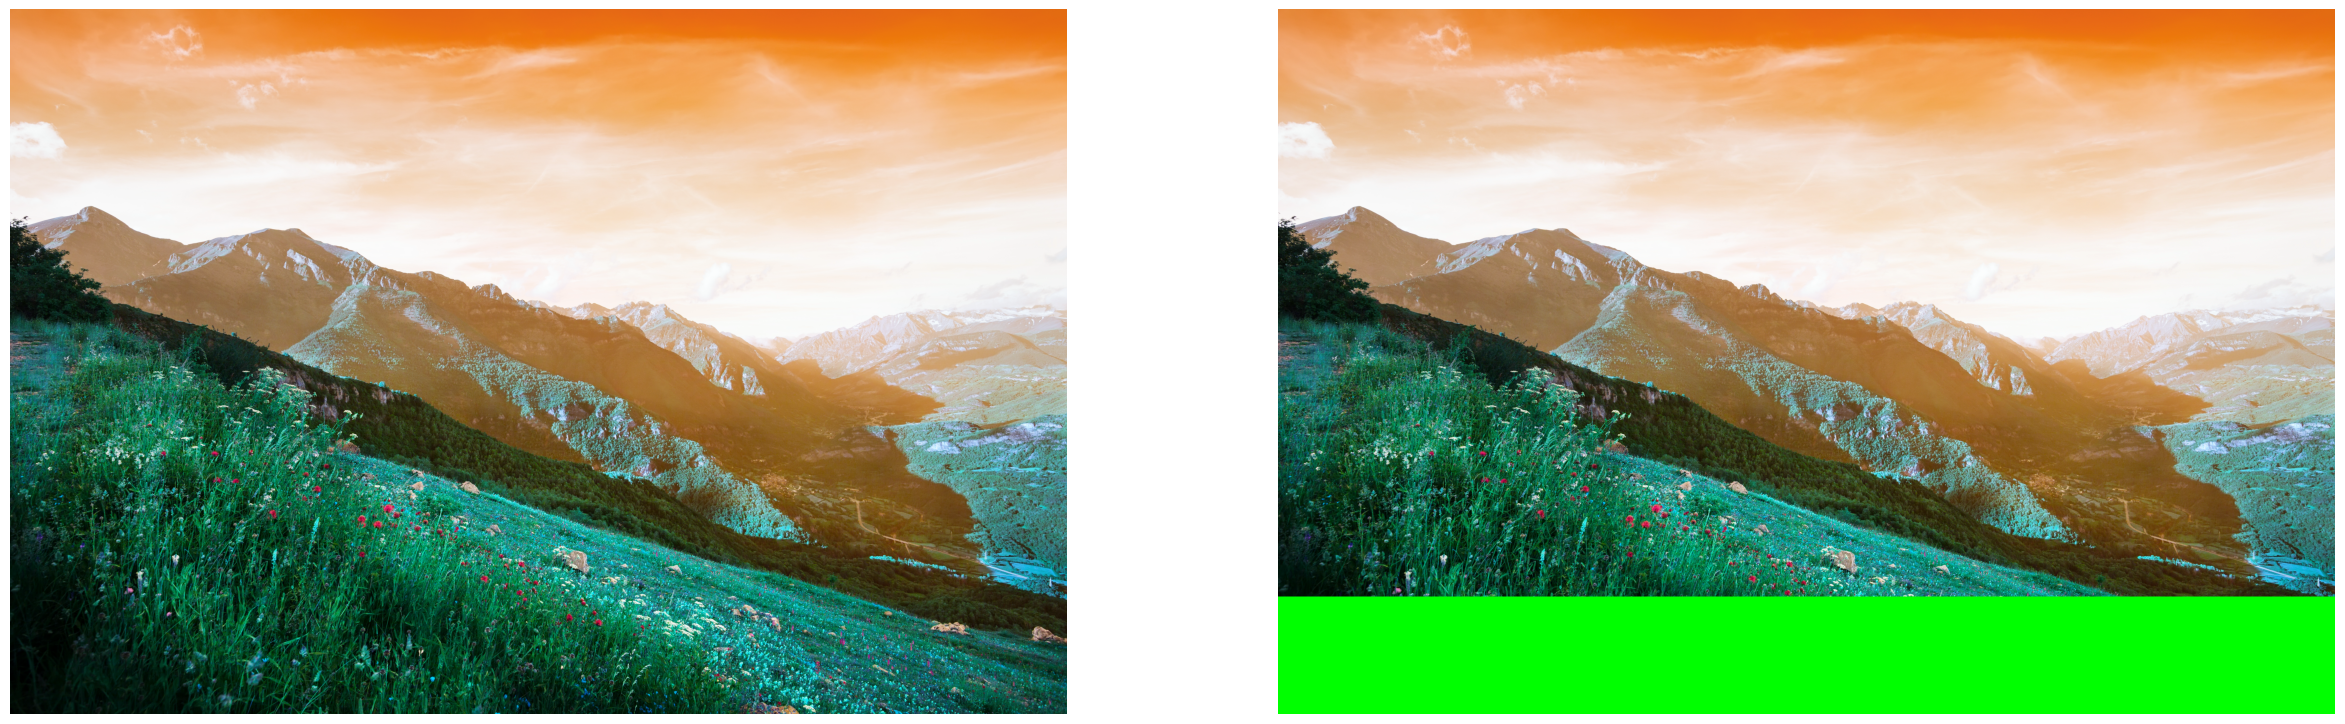

In [8]:
img_copy = img_exm.copy()
img_copy[-500:, :] = [0, 255 , 0]

plt.figure(figsize=(30, 15))
plt.subplot(1,2,1)
plt.imshow(img_exm)
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_copy)
plt.axis("off")

## Задание 5. Сравнение исходного и изменённого изображения
Чтобы корректно показать изображения через `matplotlib`, переводим их из BGR в RGB. 

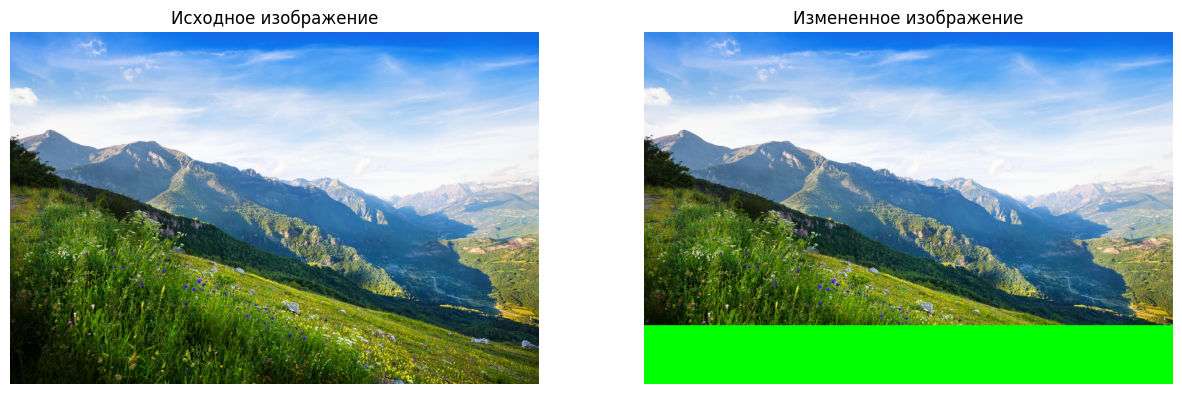

In [11]:
original_rgb = cv2.cvtColor(img_exm, cv2.COLOR_BGR2RGB)
changed_rgb = cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title("Исходное изображение")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(changed_rgb)
plt.title("Измененное изображение")
plt.axis("off")

plt.show()

## Задание 6. Анализ яркости изображения по высоте
Переводим изображение в градации серого и для каждой строки вычисляем среднюю яркость. По полученным значениям строим график и определяем, какая строка изображения в среднем самая светлая, а какая - самая тёмная.

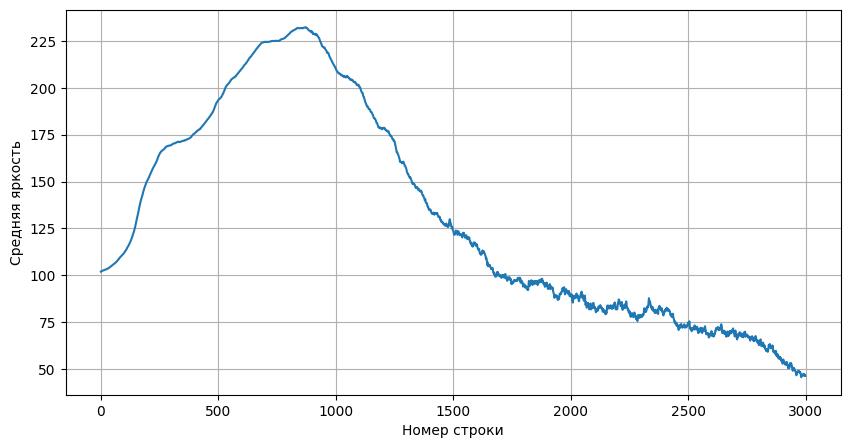

In [12]:
gray = cv2.cvtColor(img_exm, cv2.COLOR_BGR2GRAY)

mean_brightness = np.mean(gray, axis=1)

plt.figure(figsize=(10, 5))

plt.plot(mean_brightness)

plt.xlabel("Номер строки")
plt.ylabel("Средняя яркость")

plt.grid()
plt.show()

## Задание 7. Анализ цветовых каналов по ширине изображения
Для каждого столбца изображения вычисляем среднюю интенсивность красного, зелёного и синего каналов. График позволяет увидеть, какие цветовые компоненты преобладают в разных частях изображения слева направо

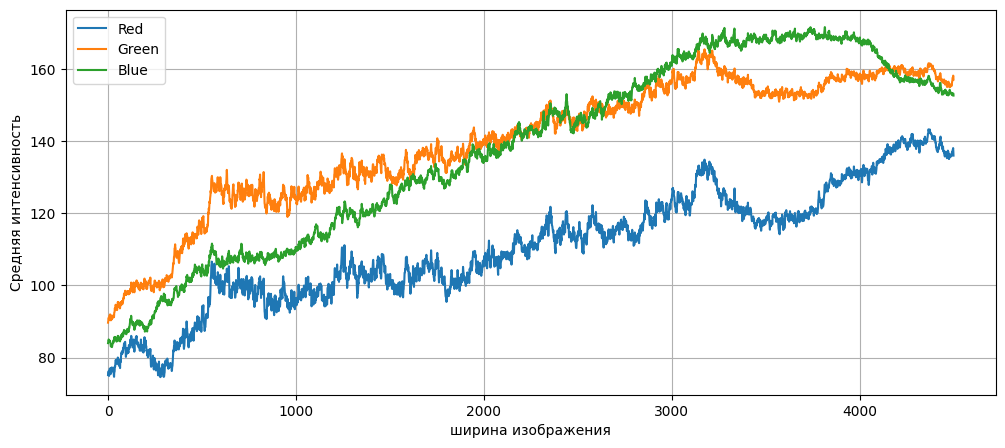

In [14]:
mean_b = np.mean(b_ch, axis=0)
mean_g = np.mean(g_ch, axis=0)
mean_r = np.mean(r_ch, axis=0)

plt.figure(figsize=(12, 5))

plt.plot(mean_r, label="Red")
plt.plot(mean_g, label="Green")
plt.plot(mean_b, label="Blue")

plt.xlabel("ширина изображения")
plt.ylabel("Средняя интенсивность")

plt.legend()
plt.grid()

plt.show()

## Задание 8. Определение доли зелёного цвета
Переводим изображение в HSV и задаём диапазон оттенков, который будем считать зелёным. С помощью маски подсчитываем количество подходящих пикселей и определяем, какую долю всего изображения они занимают.

In [16]:
hsv = cv2.cvtColor(img_exm, cv2.COLOR_BGR2HSV)

lower_green = np.array([35, 50, 50])
upper_green = np.array([85, 255, 255])

mask = cv2.inRange(hsv,lower_green,upper_green)
green_pixels = np.count_nonzero(mask)
total_pixels = mask.size
percentage = ( green_pixels / total_pixels) * 100

print("Доля зеленого цвета:", round(percentage, 2),"%")

Доля зеленого цвета: 20.26 %


In [17]:
height, width = hsv.shape[:2]
half_h = height // 2
half_w = width // 2

regions = [
            hsv[0:half_h, 0:half_w],
            hsv[0:half_h, half_w:width],
            hsv[half_h:height, 0:half_w],
            hsv[half_h:height, half_w:width]
        ]
mean_s = []
mean_v = []

for region in regions:
    saturation = region[:, :, 1]
    brightness = region[:, :, 2]

    mean_s.append(np.mean(saturation))
    mean_v.append(np.mean(brightness))

## Задание 9. Сравнение яркости и насыщенности разных частей изображения
Разделяем изображение на четыре области. Для каждой области в модели HSV вычисляем среднюю насыщенность (`S`) и среднюю яркость (`V`). Затем сравниваем эти значения на графике и определяем наиболее яркую и наиболее насыщенную область.

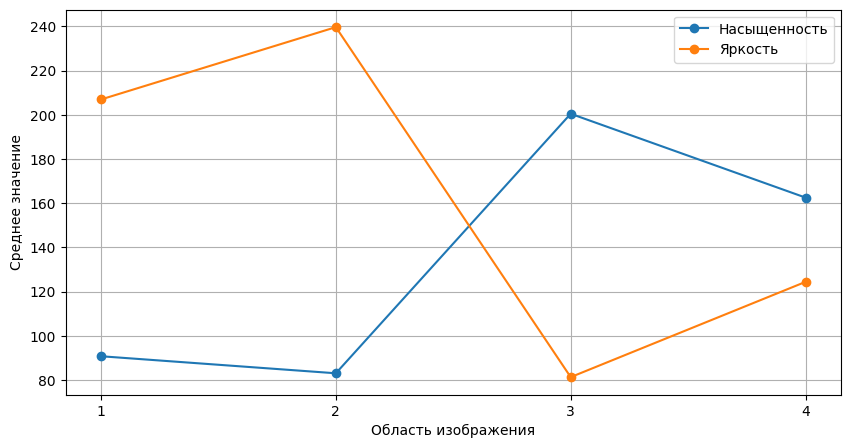

In [18]:
areas = [1, 2, 3, 4]

plt.figure(figsize=(10, 5))

plt.plot(areas,mean_s,marker="o",label="Насыщенность")

plt.plot(areas, mean_v, marker="o", label="Яркость")

plt.xticks(areas)

plt.xlabel("Область изображения")
plt.ylabel("Среднее значение")


plt.legend()
plt.grid()

plt.show()

## Задание 10. Выделение пикселей заданного цвета
Используем ту же HSV-маску зелёного цвета, но теперь применяем её к исходному изображению. Пиксели, попавшие в заданный цветовой диапазон, остаются без изменений, а остальные становятся чёрными. Результат сохраняем в отдельный файл.

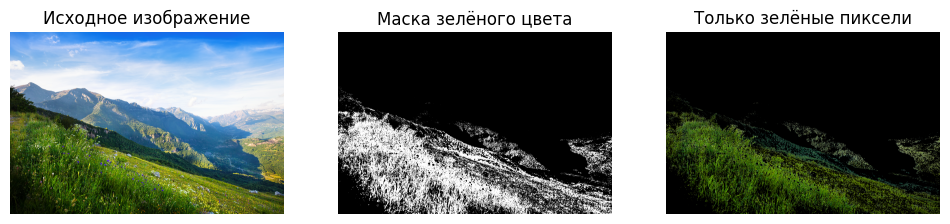

In [19]:
lower_green = np.array([35, 50, 50])
upper_green = np.array([85, 255, 255])

mask = cv2.inRange(hsv, lower_green, upper_green)

result = cv2.bitwise_and(img_exm, img_exm, mask=mask)

result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
original_rgb = cv2.cvtColor(img_exm, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_rgb)
plt.title("Исходное изображение")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Маска зелёного цвета")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(result_rgb)
plt.title("Только зелёные пиксели")
plt.axis("off")

plt.show()